In [1]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
import os
import re
import anndata as ad
import warnings
warnings.filterwarnings("ignore")
import harmonypy as hm
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import anndata
from decimal import Decimal, ROUND_HALF_UP
from plotnine import *
import itertools

In [2]:
PATH_FILESYSTEM="/data2/core-med1/elindber/"

In [3]:
random_state=10

In [4]:
def stacked_barplot(adata, xaxis, stack, xaxis_label, legend_label, shift_top=0.2, xaxis_rotation=45, figsize=(10,10), percent=True):
    tmp=pd.crosstab(adata.obs[xaxis],
                adata.obs[stack]).sum(axis=1)
    
    ax= pd.crosstab(adata.obs[xaxis], 
                    adata.obs[stack]).apply(lambda r: r/r.sum()*100, axis=1)
    #ax_1 = ax.plot.bar(figsize=(10,10),stacked=True, rot=0, colors=colors)
    ax_1 = ax.plot.bar(figsize=figsize,stacked=True, rot=0)
    #display(ax)
    #plt.legend(title="Subject") # loc='upper center', bbox_to_anchor=(0.1, 1.0), 
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title=legend_label)
    plt.xlabel(xaxis_label,fontweight="bold")
    plt.ylabel('Percent Distribution',fontweight="bold")
    
    if percent:
        for rec in ax_1.patches:
            height = rec.get_height()
            ax_1.text(rec.get_x() + rec.get_width() / 2, rec.get_y() + height/2, "{:.0f}%".format(height),
                   ha = 'center', va='center', fontsize=14.5, weight='bold') #
    
    for xaxistick in range(ax.shape[0]):
        ax_1.text(xaxistick-shift_top,110,tmp[xaxistick],va='center', rotation=45, fontsize=14.5, weight='bold')
    
    plt.xticks(rotation=xaxis_rotation)
    
    ax_1.grid(False)
    plt.show()

In [5]:
def filter_by_expression(adata_obj, DE_column, key='rank_genes_groups'):
#adata_obj=fbs_new_harmony.copy()
#key='rank_genes_groups'
#DE_column='leiden'
    def to_tensor(dataframe, columns = [], dtypes = {}, index = False):
        to_records_kwargs = {'index': index}
        if not columns:  # Default to all `dataframe.columns`
            columns = dataframe.columns
        if dtypes:       # Pull in modifications only for dtypes listed in `columns`
            to_records_kwargs['column_dtypes'] = {}
            for column in dtypes.keys():
                if column in columns:
                    to_records_kwargs['column_dtypes'].update({column: dtypes.get(column)})
        return dataframe[columns].to_records(**to_records_kwargs)
    gene_names = pd.DataFrame(adata_obj.uns[key]['names'])
    fraction_in_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    fraction_notin_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    in_cluster_expr_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    notin_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    allin_cluster_expr_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    allnotin_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    # Create a Adata raw with raw in .X -> We might remove this step - redundant!
    dummy=anndata.AnnData(X=adata_obj.raw.X,
                   var=adata_obj.raw.var,
                   obs=adata_obj.obs)
    # We split the adata by Cell-type. Genes are ordered according to ranks from DEgene analysis
    dummy_split=[dummy[dummy.obs[DE_column].isin([i]),
                  gene_names[i]] for i in gene_names.columns]
    dummy_split_adatasize=[i.shape[0] for i in dummy_split] # How many cells we have in-cluster
    dummy_outcluster=[dummy[~dummy.obs[DE_column].isin([i]),
                       gene_names[i]] for i in gene_names.columns]
    dummy_split_adatasize_outcluster=[i.shape[0] for i in dummy_outcluster] # How many cells we have in out-cluster
    for adata, sizeof_adata, adata_outcluster, sizeof_adata_outcluster in zip(dummy_split, dummy_split_adatasize, 
                                                     dummy_outcluster, dummy_split_adatasize_outcluster):
        cluster_number=[(adata.obs[DE_column].unique()).tolist()][0]
        #incluster_rows, incluster_cols=adata.X.nonzero()
        #https://stackoverflow.com/questions/3797158/counting-non-zero-elements-within-each-row-and-within-each-column-of-a-2d-numpy
        #incluster_counts = [len(np.where(incluster_cols==i)[0]) for i in range(0,adata.shape[1])]
        incluster_counts=np.diff(adata.X.tocsc().indptr)
        percent_expression_incluster=np.array(incluster_counts)/sizeof_adata 
        fraction_in_cluster_matrix[cluster_number[0]]=percent_expression_incluster
        #outcluster_rows, outcluster_cols=adata_outcluster.X.nonzero()
        #outcluster_counts = [len(np.where(outcluster_cols==i)[0]) for i in range(0,adata_outcluster.shape[1])]
        outcluster_counts=np.diff(adata_outcluster.X.tocsc().indptr)
        percent_expression_outcluster=np.array(outcluster_counts)/sizeof_adata_outcluster 
        fraction_notin_cluster_matrix[cluster_number[0]]=percent_expression_outcluster
        # Expression_all in cluster
        allin_cluster_expr_matrix[cluster_number[0]]=np.squeeze(np.asarray(adata.X.mean(axis=0)))
        allnotin_cluster_matrix[cluster_number[0]]=np.squeeze(np.asarray(adata_outcluster.X.mean(axis=0)))
    # Generate the last table results
    result = adata_obj.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    result['pi'] = to_tensor(fraction_in_cluster_matrix)
    result['po'] = to_tensor(fraction_notin_cluster_matrix)
    result['ei'] = to_tensor(allin_cluster_expr_matrix)
    result['eo'] = to_tensor(allnotin_cluster_matrix)
    results =pd.DataFrame(
        {group + '_' + key[:2]: result[key][group]
        for group in groups for key in ['names', 'pvals_adj', 'logfoldchanges', 'pi', 'po', "ei", "eo"]})
    return results

In [63]:
def makevector_topmarkers(anndata, top_n, ldFC_cutoff=0.5, pvals_adj_cutoff=10**-30, expression_in=1, expression_out=0.4): 
    results=anndata.uns['rank_genes_groups']
    clusters = results['names'].dtype.names
    top_genes=[]
    for cluster in clusters:
        topgenes_cluster=results['names'][cluster][np.where((results['logfoldchanges'][cluster]>=ldFC_cutoff) & 
                                                            (results['pvals_adj'][cluster]<(pvals_adj_cutoff)) &
                                                           (results['ei'][cluster]>=expression_in) & 
                                                            (results['eo'][cluster]<=expression_out)
                                                           )][0:top_n]
        top_genes.extend(topgenes_cluster)
    return(top_genes)

In [7]:
def correlation_analysis(scanpy_object, column_tosplitby, sum_or_mean):
    d = {}
    for cluster_number in np.unique(scanpy_object.obs[column_tosplitby].values):
        #cluster_number=np.unique(heart.obs['louvain_annotated'].values)[1]
        scanpy_object_subset = scanpy_object[scanpy_object.obs[column_tosplitby].isin([cluster_number])]

        if sum_or_mean=="mean":
            d[cluster_number] = np.squeeze(np.asarray(scanpy_object_subset.raw.X.mean(axis=0))) #np.log(+1)
        elif sum_or_mean=="sum":
            d[cluster_number] = np.squeeze(np.asarray(scanpy_object_subset.raw.X.sum(axis=0))) #np.log(+1)
        del scanpy_object_subset
        
    return d

In [8]:
PATH_FILESYSTEM+"PROJECTS/20231020_el_Xenotransplant/results/"

'/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/results/'

In [9]:
all_samples_h5ad_all=sc.read_h5ad(PATH_FILESYSTEM+"PROJECTS/20231020_el_Xenotransplant/results/20240220_el_Xenotransplant_BR_Fibroblasts_PIG_RAW.h5ad")

# Step1: Subclustering

In [10]:
sc.pp.normalize_total(all_samples_h5ad_all, target_sum=1e4)

In [11]:
sc.pp.log1p(all_samples_h5ad_all)

In [12]:
all_samples_h5ad_all.raw=all_samples_h5ad_all

In [13]:
sc.pp.highly_variable_genes(all_samples_h5ad_all, min_mean=0.02, max_mean=3, min_disp=0.5)
#sc.pp.highly_variable_genes(all_samples_h5ad_all, min_mean=0.01, max_mean=3, min_disp=0.5)

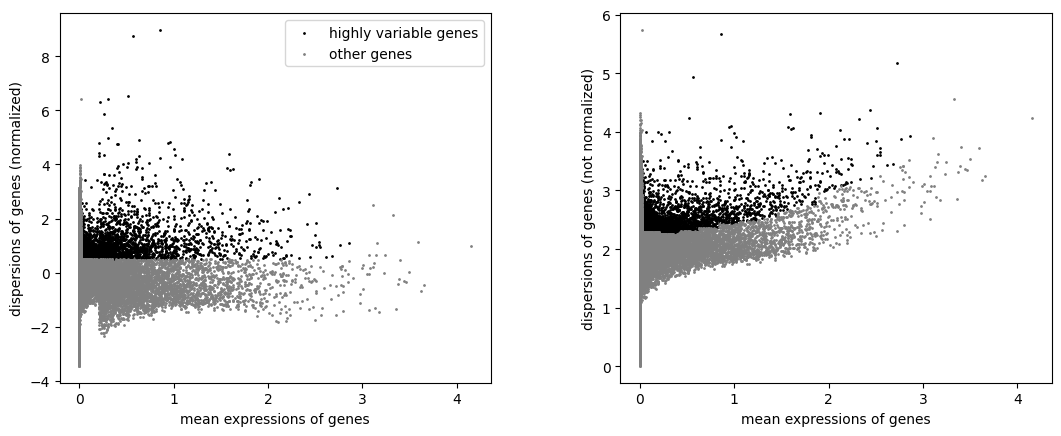

In [14]:
sc.pl.highly_variable_genes(all_samples_h5ad_all)

In [15]:
all_samples_h5ad_all = all_samples_h5ad_all[:, all_samples_h5ad_all.var.highly_variable]

In [16]:
#sc.pp.regress_out(all_samples_h5ad_all, ['n_counts'])

In [17]:
sc.pp.scale(all_samples_h5ad_all, max_value=10)

In [18]:
sc.tl.pca(all_samples_h5ad_all, svd_solver='arpack')
#sc.pl.pca(all_baboonspig_merged_filtered, color='TTN')

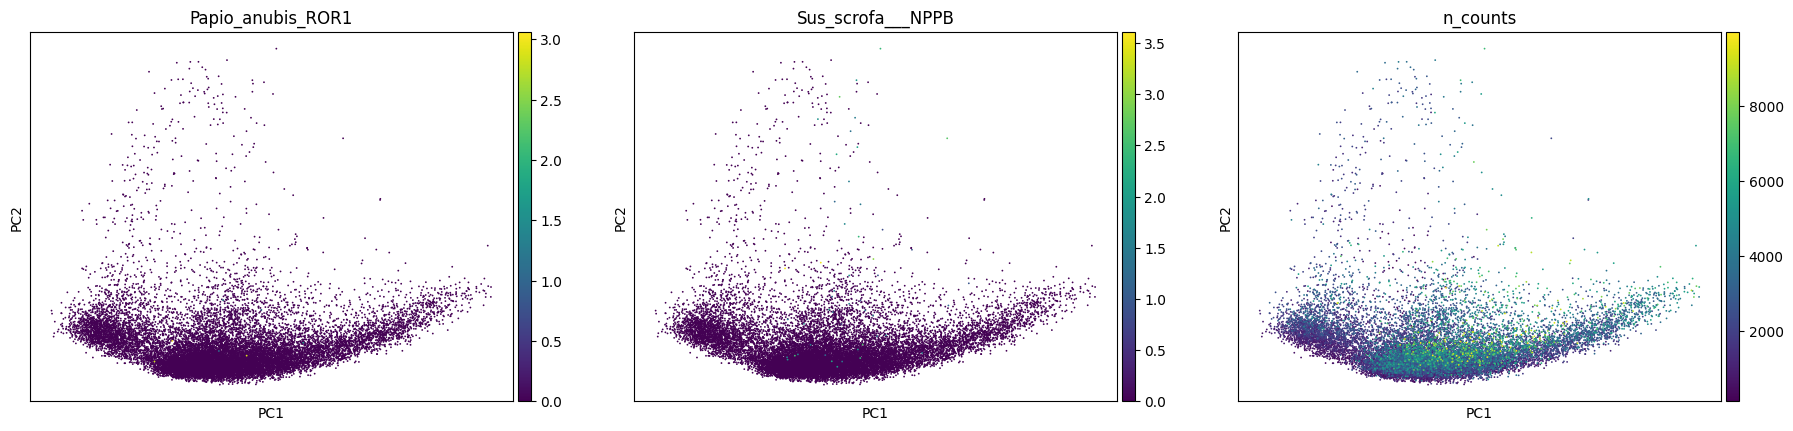

In [19]:
sc.pl.pca(all_samples_h5ad_all, color=['Papio_anubis_ROR1','Sus_scrofa___NPPB', 'n_counts'])

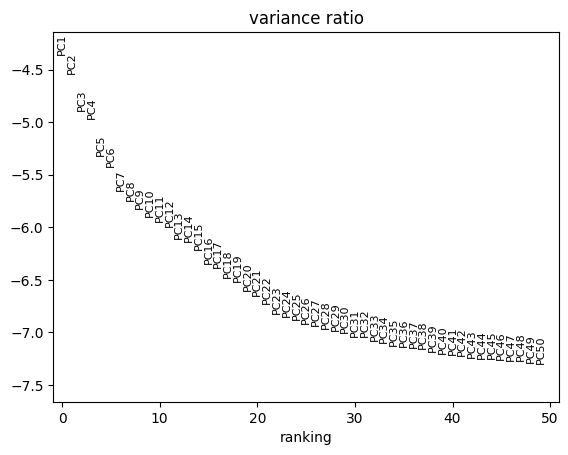

In [20]:
sc.pl.pca_variance_ratio(all_samples_h5ad_all, log=True, n_pcs=50)

In [21]:
num_pcs=38
#num_pcs=45
pca=all_samples_h5ad_all.obsm['X_pca']
meta_data=all_samples_h5ad_all.obs
GLOBAL_harmony=all_samples_h5ad_all.copy()

In [22]:
ho=hm.run_harmony(pca, meta_data, ['Sample_ID'],
                  epsilon_harmony=-float('Inf'), epsilon_cluster=-float('Inf'),
                  random_state=10)

2025-01-28 13:25:50,751 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-01-28 13:25:55,705 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-28 13:25:55,782 - harmonypy - INFO - Iteration 1 of 10
2025-01-28 13:25:59,285 - harmonypy - INFO - Iteration 2 of 10
2025-01-28 13:26:02,759 - harmonypy - INFO - Iteration 3 of 10
2025-01-28 13:26:06,256 - harmonypy - INFO - Iteration 4 of 10
2025-01-28 13:26:09,751 - harmonypy - INFO - Iteration 5 of 10
2025-01-28 13:26:13,210 - harmonypy - INFO - Iteration 6 of 10
2025-01-28 13:26:16,695 - harmonypy - INFO - Iteration 7 of 10
2025-01-28 13:26:20,143 - harmonypy - INFO - Iteration 8 of 10
2025-01-28 13:26:23,650 - harmonypy - INFO - Iteration 9 of 10
2025-01-28 13:26:27,144 - harmonypy - INFO - Iteration 10 of 10
2025-01-28 13:26:30,616 - harmonypy - INFO - Stopped before convergence


In [23]:
res=pd.DataFrame(ho.Z_corr)
res=res.T
GLOBAL_harmony.obsm['X_pca']=res.values

In [24]:
#GLOBAL_harmony.write(PATH_FILESYSTEM+"PROJECTS/20231020_el_Xenotransplant/results/V2/20241024_el_Xenotransplant_BR_harmonypc39_noreg.h5ad")
#GLOBAL_harmony=sc.read_h5ad("/archive1/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/results/20240220_el_Xenotransplant_noBR_harmony.h5ad")

In [25]:
sc.pp.neighbors(GLOBAL_harmony, n_neighbors=50, n_pcs=num_pcs, random_state=random_state)
#sc.pp.neighbors(GLOBAL_harmony, n_neighbors=50, n_pcs=num_pcs, random_state=random_state)

In [26]:
sc.tl.umap(GLOBAL_harmony, random_state=random_state, min_dist=0.1, spread=2, n_components=2)
#sc.tl.umap(GLOBAL_harmony, random_state=random_state, min_dist=0.2, spread=2, n_components=2)

In [27]:
sc.tl.leiden(GLOBAL_harmony, 
             resolution=0.7, random_state=random_state, key_added="leiden_08")

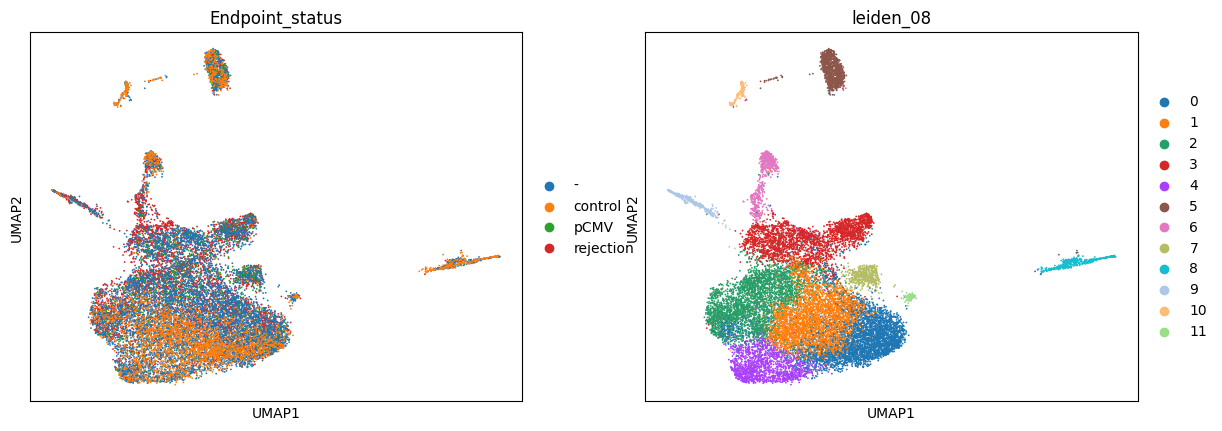

In [28]:
sc.pl.umap(GLOBAL_harmony, color=['Endpoint_status', 'leiden_08'],
           projection="2d", components=['1,2'], show=True)

In [29]:
GLOBAL_harmony

AnnData object with n_obs × n_vars = 18120 × 3147
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'leiden_08'
    var: 'Average_expression', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sample_ID_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'Endpoint_status_colors', 'leiden_08_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

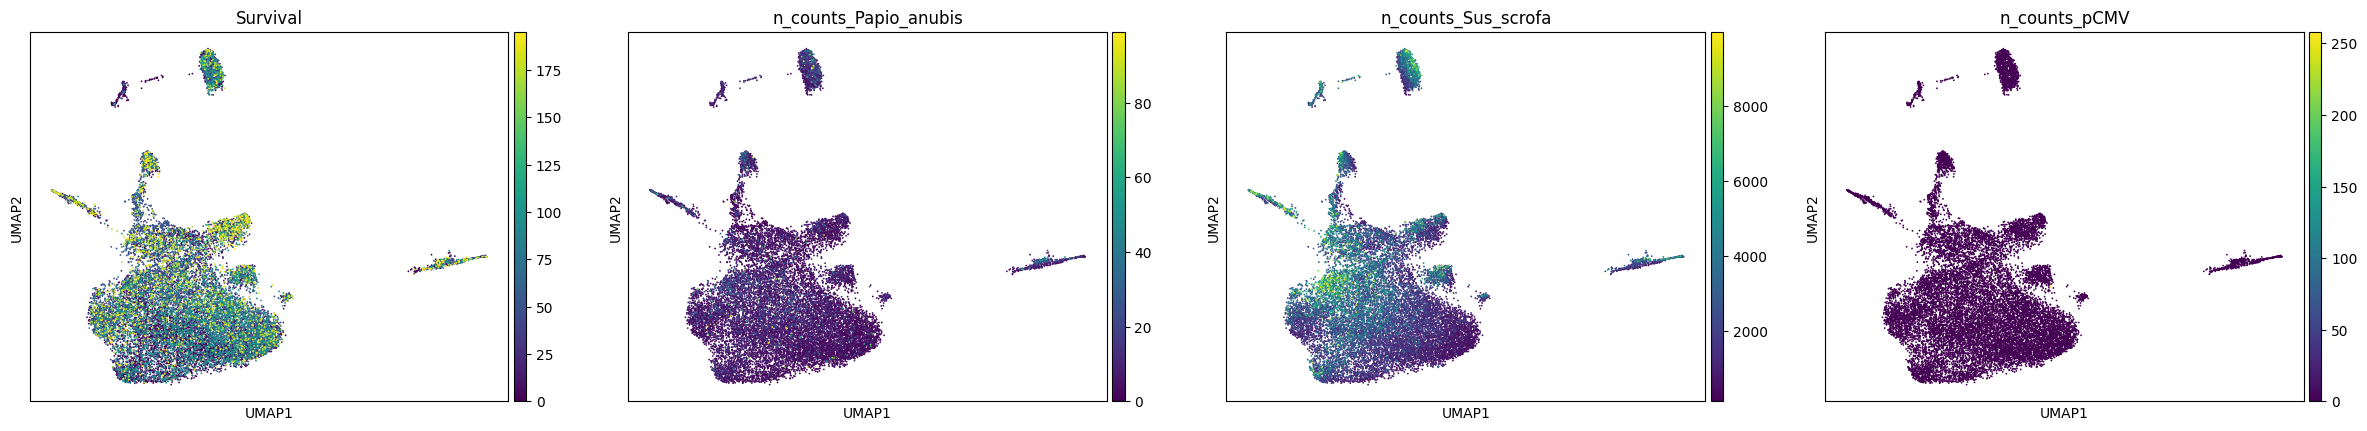

In [30]:
sc.pl.umap(GLOBAL_harmony, color=['Survival', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa','n_counts_pCMV'],
           projection="2d", components=['1,2'], show=True)

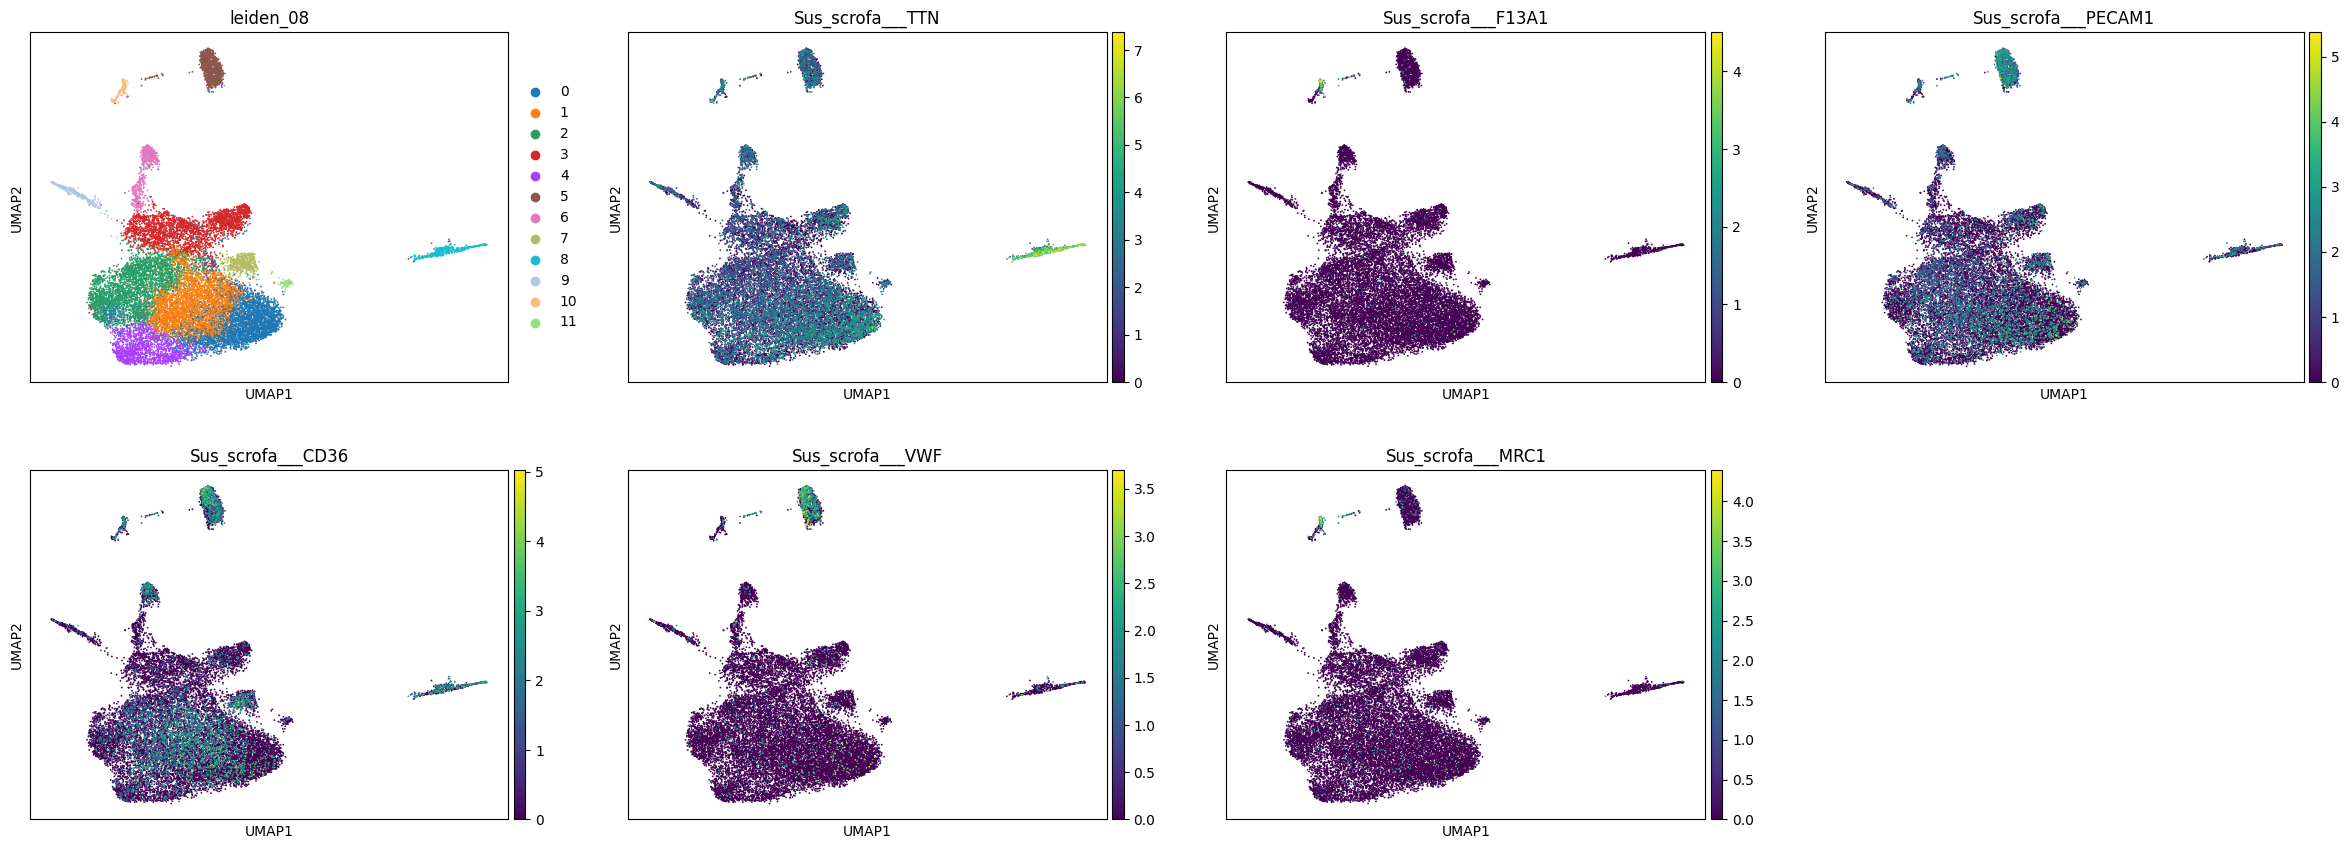

In [38]:
sc.pl.umap(GLOBAL_harmony, color=['leiden_08', 'Sus_scrofa___TTN', 'Sus_scrofa___F13A1', 'Sus_scrofa___PECAM1', 'Sus_scrofa___CD36', 'Sus_scrofa___VWF','Sus_scrofa___MRC1'],
           projection="2d", components=['1,2'], show=True)

In [40]:
sc.tl.rank_genes_groups(GLOBAL_harmony, 'leiden_08', method='wilcoxon')#, n_genes=GLOBAL_harmony.raw.X.shape[1])
df=filter_by_expression(GLOBAL_harmony, 'leiden_08', key='rank_genes_groups')

In [43]:
df.iloc[:,63:70].head(n=20)

,9_na,9_pv,9_lo,9_pi,9_po,9_ei,9_eo
0,Sus_scrofa___DIAPH3,1.618988e-141,7.636136,0.783069,0.023447,2.283267,0.043327
1,Sus_scrofa___ATAD2,3.860943e-98,4.778423,0.698413,0.062789,1.472969,0.115567
2,Sus_scrofa___EZH2,7.204196e-69,4.451094,0.589947,0.051065,1.114928,0.089559
3,Sus_scrofa___SMC4,3.148517e-68,3.637327,0.626984,0.088434,1.154873,0.160995
4,Sus_scrofa___CIT,1.388840e-62,5.943412,0.531746,0.014654,0.968782,0.026218
5,Sus_scrofa___NCAPG,2.722081e-61,6.988321,0.518519,0.007384,0.932370,0.012060
6,Sus_scrofa___MAST2,4.354813e-59,2.954761,0.640212,0.156070,1.211295,0.265527
7,Sus_scrofa___ANLN,5.510115e-58,5.769773,0.513228,0.016909,0.944274,0.028386
8,Sus_scrofa___ENSSSCG00000035544,5.510115e-58,3.015002,0.621693,0.144009,1.117187,0.226635
9,Sus_scrofa___KNTC1,3.424160e-54,5.387144,0.500000,0.018882,0.860848,0.032100


In [48]:
#df.iloc[:,91:105].head(n=40)
#gene_names=df.iloc[:,91:105].head(n=40)['14_na']
#df.iloc[:,28:35].head(n=40)

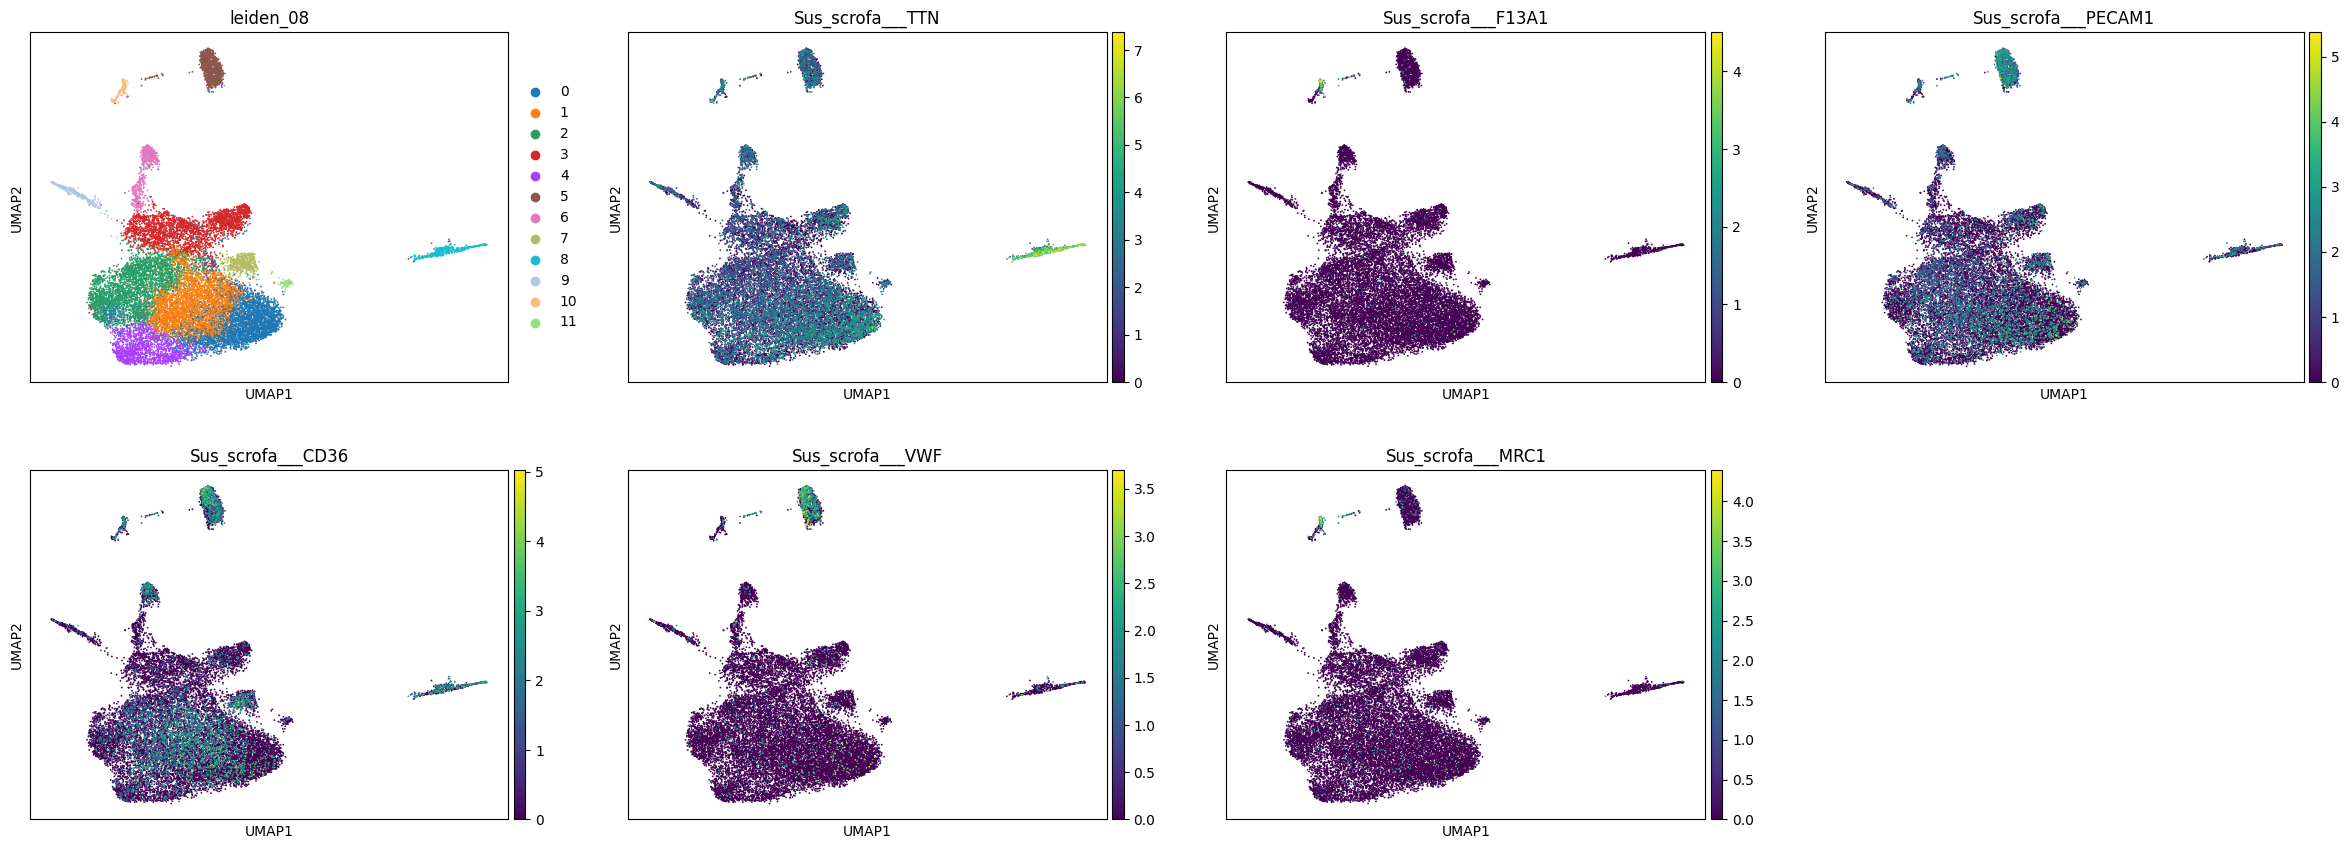

In [49]:
sc.pl.umap(GLOBAL_harmony, color=['leiden_08', 'Sus_scrofa___TTN', 'Sus_scrofa___F13A1', 'Sus_scrofa___PECAM1', 'Sus_scrofa___CD36', 'Sus_scrofa___VWF','Sus_scrofa___MRC1'],
           projection="2d", components=['1,2'], show=True)

In [50]:
GLOBAL_harmony.obs['cell_states']=GLOBAL_harmony.obs['leiden_08']
subs = {
    "0":'FB', 
    "1":'FB',
    "2":'FB',
    "3":'FB',
    "4":'FB',
    "5":'unassigned',
    "6":'FB',
    "7":'FB',
    '8':'unassigned',
    '9':'FB',
    '10':"unassigned",
    '11':"FB",
     } 
# PC-like, EC-like, MP-like, MP_interacting, CM-like, ECM_r, CST3+, ECM_p, Canonical, DAAM1+
x=[subs.get(item,item)  for item in GLOBAL_harmony.obs['cell_states']]
GLOBAL_harmony.obs['cell_states']=x
pd.value_counts(GLOBAL_harmony.obs['cell_states'])/GLOBAL_harmony.shape[0]

cell_states
FB            0.900773
unassigned    0.099227
Name: count, dtype: float64

In [51]:
GLOBAL_harmony

AnnData object with n_obs × n_vars = 18120 × 3147
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'leiden_08', 'cell_states'
    var: 'Average_expression', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sample_ID_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'Endpoint_status_colors', 'leiden_08_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [52]:
GLOBAL_harmony.write(PATH_FILESYSTEM+"PROJECTS/20231020_el_Xenotransplant/results/20240220_el_Xenotransplant_BR_FB_PIG_1stIT_ANNOTATED.h5ad")
#GLOBAL_1stit=sc.read_h5ad(PATH_FILESYSTEM+"PROJECTS/20231020_el_Xenotransplant/results/20240220_el_Xenotransplant_BR_FB_PIG_1stIT_ANNOTATED.h5ad")

# Step2: Multiplet removal

In [9]:
all_samples_h5ad_all=sc.read_h5ad(PATH_FILESYSTEM+"PROJECTS/20231020_el_Xenotransplant/results/20240220_el_Xenotransplant_BR_Fibroblasts_PIG_RAW.h5ad")

In [10]:
GLOBAL_harmony=sc.read_h5ad(PATH_FILESYSTEM+"PROJECTS/20231020_el_Xenotransplant/results/20240220_el_Xenotransplant_BR_FB_PIG_1stIT_ANNOTATED.h5ad")

In [11]:
if all(all_samples_h5ad_all.obs.index == GLOBAL_harmony.obs.index):
    all_samples_h5ad_all.obs=GLOBAL_harmony.obs
    print("OK")

OK


In [12]:
all_samples_h5ad_all=all_samples_h5ad_all[["unassigned" not in i for i in all_samples_h5ad_all.obs.cell_states]].copy()

In [13]:
sc.pp.normalize_total(all_samples_h5ad_all, target_sum=1e4)

In [14]:
sc.pp.log1p(all_samples_h5ad_all)

In [15]:
all_samples_h5ad_all.raw=all_samples_h5ad_all

In [16]:
sc.pp.highly_variable_genes(all_samples_h5ad_all, min_mean=0.0125, max_mean=3, min_disp=0.5)
#sc.pp.highly_variable_genes(all_samples_h5ad_all, min_mean=0.01, max_mean=3, min_disp=0.5)

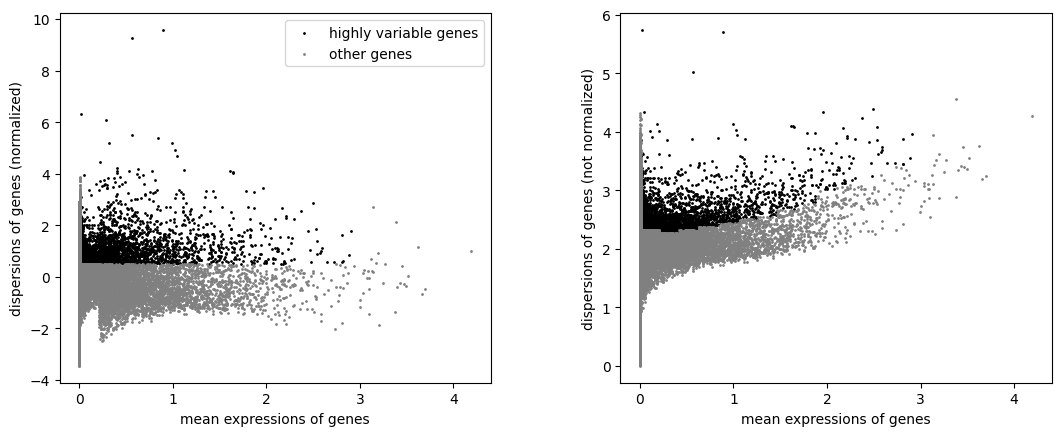

In [17]:
sc.pl.highly_variable_genes(all_samples_h5ad_all)

In [18]:
all_samples_h5ad_all = all_samples_h5ad_all[:, all_samples_h5ad_all.var.highly_variable]

In [19]:
#sc.pp.regress_out(all_samples_h5ad_all, ['n_counts'])

In [20]:
sc.pp.scale(all_samples_h5ad_all, max_value=10)

In [21]:
sc.tl.pca(all_samples_h5ad_all, svd_solver='arpack')
#sc.pl.pca(all_baboonspig_merged_filtered, color='TTN')

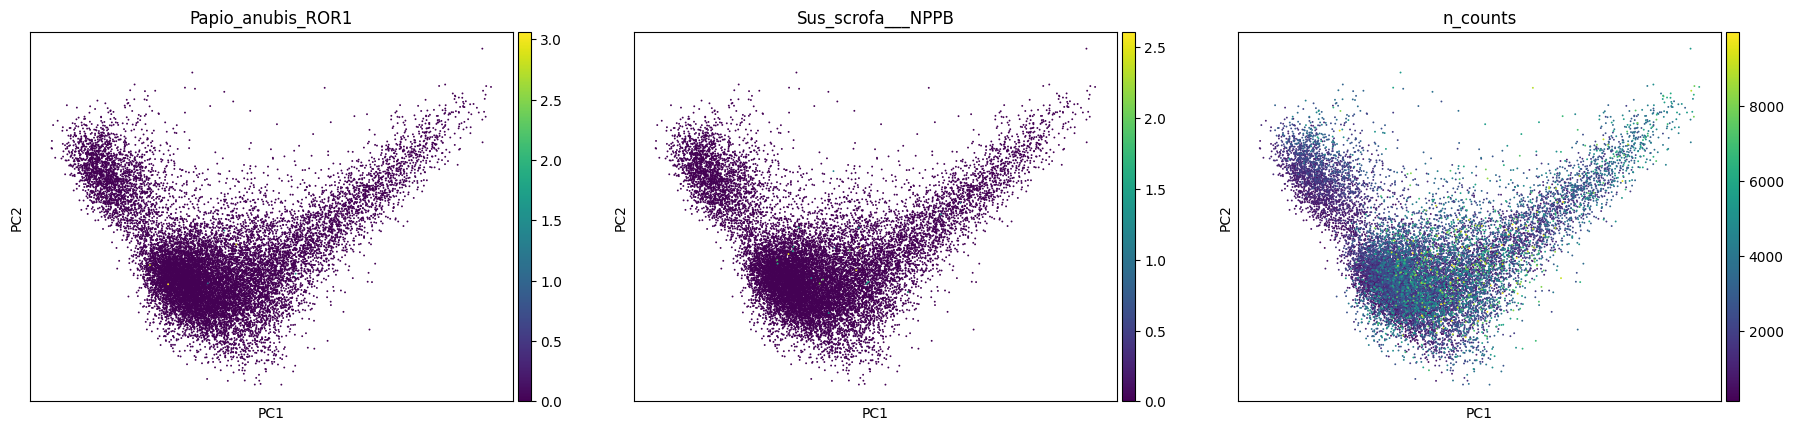

In [22]:
sc.pl.pca(all_samples_h5ad_all, color=['Papio_anubis_ROR1','Sus_scrofa___NPPB', 'n_counts'])

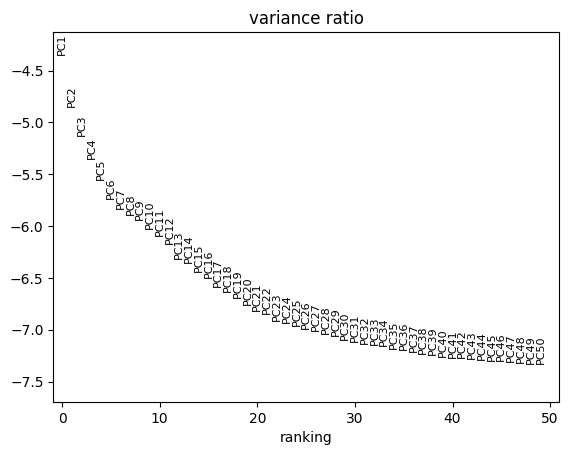

In [23]:
sc.pl.pca_variance_ratio(all_samples_h5ad_all, log=True, n_pcs=50)

In [24]:
num_pcs=29
#num_pcs=30
pca=all_samples_h5ad_all.obsm['X_pca']
meta_data=all_samples_h5ad_all.obs
GLOBAL_harmony=all_samples_h5ad_all.copy()

In [25]:
ho=hm.run_harmony(pca, meta_data, ['Sample_ID'],
                  epsilon_harmony=-float('Inf'), epsilon_cluster=-float('Inf'),
                  random_state=10)

2025-04-24 09:36:11,180 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-04-24 09:36:15,848 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-04-24 09:36:15,920 - harmonypy - INFO - Iteration 1 of 10
2025-04-24 09:36:19,266 - harmonypy - INFO - Iteration 2 of 10
2025-04-24 09:36:22,637 - harmonypy - INFO - Iteration 3 of 10
2025-04-24 09:36:26,044 - harmonypy - INFO - Iteration 4 of 10
2025-04-24 09:36:29,432 - harmonypy - INFO - Iteration 5 of 10
2025-04-24 09:36:32,856 - harmonypy - INFO - Iteration 6 of 10
2025-04-24 09:36:36,264 - harmonypy - INFO - Iteration 7 of 10
2025-04-24 09:36:39,640 - harmonypy - INFO - Iteration 8 of 10
2025-04-24 09:36:43,008 - harmonypy - INFO - Iteration 9 of 10
2025-04-24 09:36:46,370 - harmonypy - INFO - Iteration 10 of 10
2025-04-24 09:36:49,710 - harmonypy - INFO - Stopped before convergence


In [26]:
res=pd.DataFrame(ho.Z_corr)
res=res.T
GLOBAL_harmony.obsm['X_pca']=res.values

In [27]:
sc.pp.neighbors(GLOBAL_harmony, n_neighbors=50, n_pcs=num_pcs, random_state=random_state)

In [28]:
sc.tl.umap(GLOBAL_harmony, random_state=random_state, min_dist=0.2, spread=1, n_components=2)

In [29]:
sc.tl.leiden(GLOBAL_harmony, 
             resolution=0.7, random_state=random_state, key_added="leiden_07")

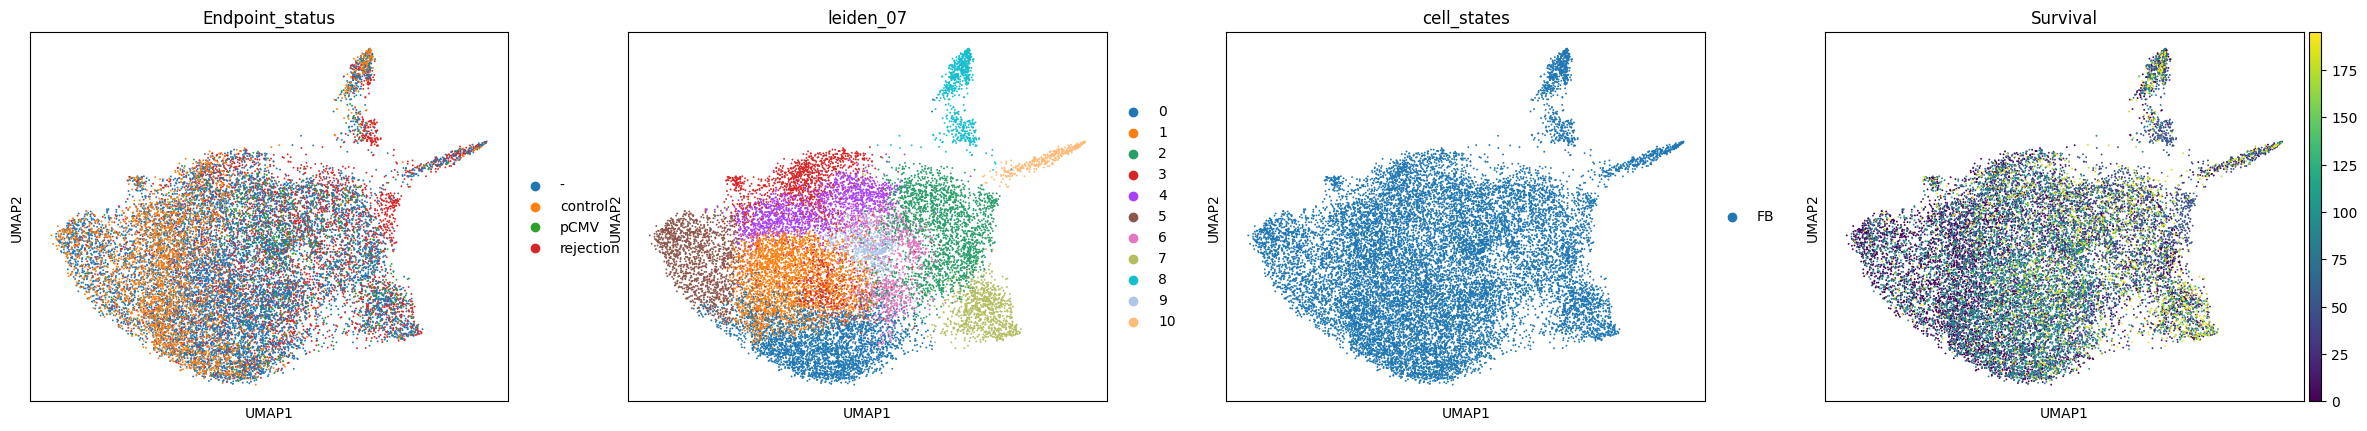

In [30]:
sc.pl.umap(GLOBAL_harmony, color=['Endpoint_status', 'leiden_07', 'cell_states', 'Survival'],
           projection="2d", components=['1,2'], show=True)

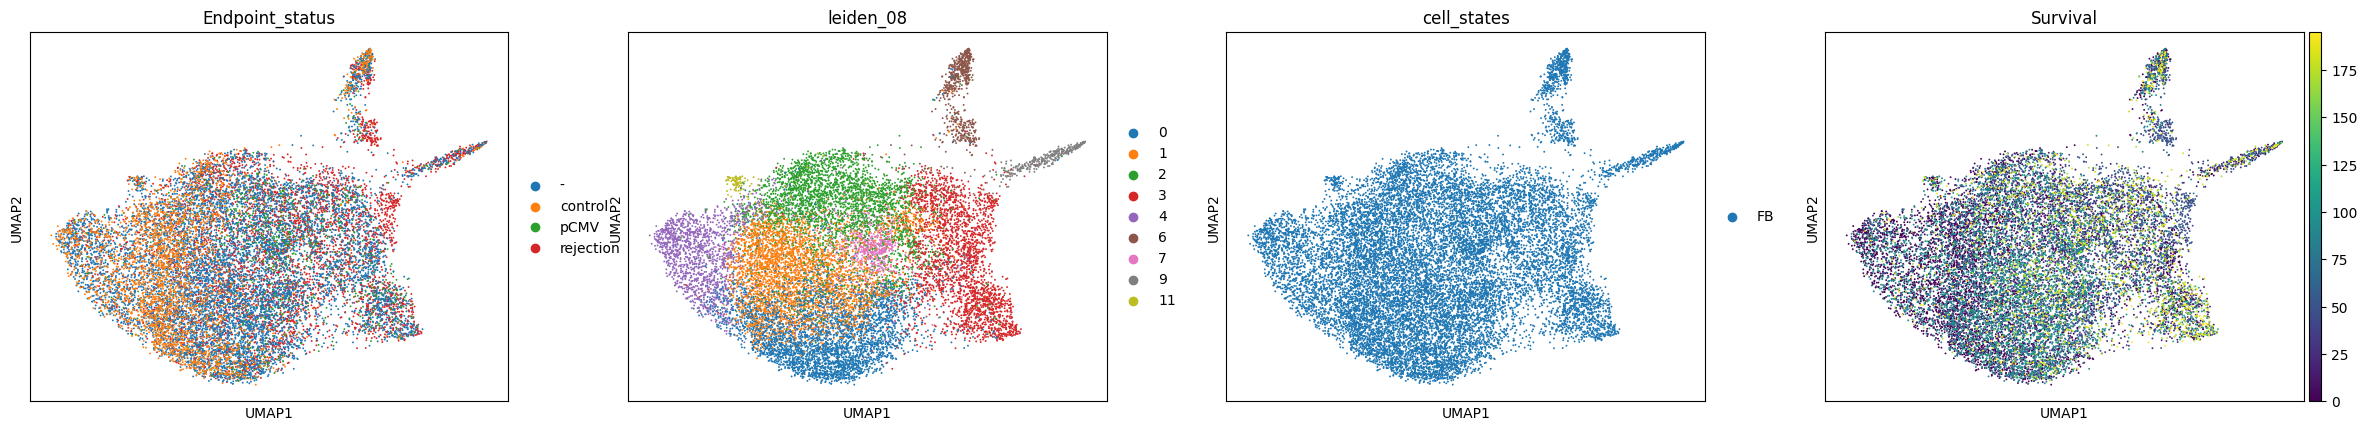

In [31]:
sc.pl.umap(GLOBAL_harmony, color=['Endpoint_status', 'leiden_08', 'cell_states', 'Survival'],
           projection="2d", components=['1,2'], show=True)

In [32]:
#sc.pl.umap(GLOBAL_harmony, color=[''],
#           projection="2d", components=['1,2'], show=True)

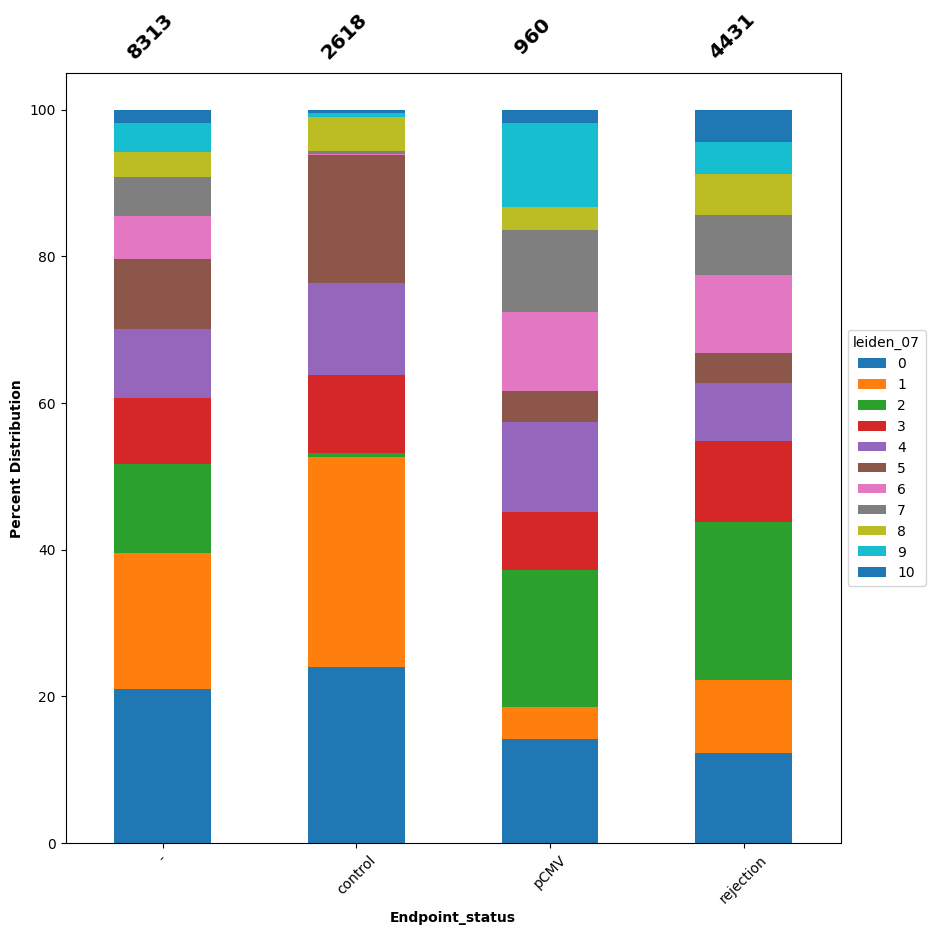

In [33]:
stacked_barplot(GLOBAL_harmony, 'Endpoint_status', 'leiden_07',
                'Endpoint_status', 'leiden_07', 
                shift_top=0.2, xaxis_rotation=45, 
                figsize=(10,10), percent=False)

In [34]:
sc.tl.rank_genes_groups(GLOBAL_harmony, 'leiden_07', method='wilcoxon', n_genes=GLOBAL_harmony.raw.X.shape[1])
df=filter_by_expression(GLOBAL_harmony, 'leiden_07', key='rank_genes_groups')

In [35]:
df

,0_na,0_pv,0_lo,0_pi,0_po,0_ei,0_eo,1_na,1_pv,1_lo,...,9_po,9_ei,9_eo,10_na,10_pv,10_lo,10_pi,10_po,10_ei,10_eo
0,Sus_scrofa___PID1,5.086916e-43,0.366610,0.778251,0.820559,3.043895,2.803468,Sus_scrofa___ABCA6,7.564204e-257,2.088725,...,0.252186,2.394311,0.582374,Sus_scrofa___DIAPH3,6.884538e-144,7.836007,0.792000,0.021383,2.314770,0.039149
1,Sus_scrofa___TTN,1.632292e-40,0.801702,0.514576,0.521139,1.655236,1.232298,Sus_scrofa___CCBE1,1.305701e-238,1.539030,...,0.218038,2.058826,0.468159,Sus_scrofa___ATAD2,2.497473e-98,4.894233,0.698667,0.058193,1.483876,0.108557
2,Sus_scrofa___ENSSSCG00000044700,9.192629e-29,0.174454,0.740583,0.842264,2.673483,2.561386,Sus_scrofa___SVEP1,1.180877e-215,2.001727,...,0.163209,1.828630,0.337438,Sus_scrofa___SMC4,1.685431e-71,3.780720,0.637333,0.081018,1.173929,0.150654
3,Sus_scrofa___LAMC1,8.223797e-27,0.052527,0.746479,0.862537,2.540234,2.506748,Sus_scrofa___PLPP4,2.756718e-211,1.934230,...,0.217527,1.932843,0.458113,Sus_scrofa___EZH2,2.780131e-70,4.573817,0.594667,0.047219,1.131449,0.084511
4,Sus_scrofa___NFIA,4.788776e-21,0.009197,0.858500,0.937900,3.242329,3.236199,Sus_scrofa___MAML2,7.156382e-206,1.167688,...,0.146422,1.807764,0.303600,Sus_scrofa___CIT,3.278374e-61,6.010504,0.528000,0.013545,0.959388,0.024668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53821,Sus_scrofa___ENSSSCG00000012262,2.816616e-144,-1.871583,0.136587,0.474339,0.332942,0.894323,Sus_scrofa___VCAN,1.872552e-78,-1.165460,...,0.425289,0.715096,1.100061,Sus_scrofa___MAML2,7.137617e-23,-0.796408,0.858667,0.861855,2.363792,2.875094
53822,Sus_scrofa___AFF4,8.030758e-149,-1.930432,0.137570,0.475469,0.328045,0.908216,Sus_scrofa___RAI14,7.787516e-82,-1.543262,...,0.350801,0.449305,0.779453,Sus_scrofa___PLXDC2,6.913038e-23,-0.867988,0.861333,0.875901,2.389542,2.948856
53823,Sus_scrofa___ANKRD17,4.677215e-151,-1.701014,0.203079,0.571332,0.519612,1.167940,Sus_scrofa___ROR1,4.764729e-86,-1.370567,...,0.873684,2.575037,2.855607,Sus_scrofa___EBF1,2.095741e-28,-0.954373,0.930667,0.940867,3.020261,3.657888
53824,Sus_scrofa___MEF2A,1.275000e-160,-1.877152,0.158533,0.521215,0.404947,1.041650,Sus_scrofa___FN1,1.166130e-88,-1.877583,...,0.641667,1.282202,1.631544,Sus_scrofa___LAMC1,2.666968e-29,-0.953088,0.816000,0.841412,1.938052,2.526530


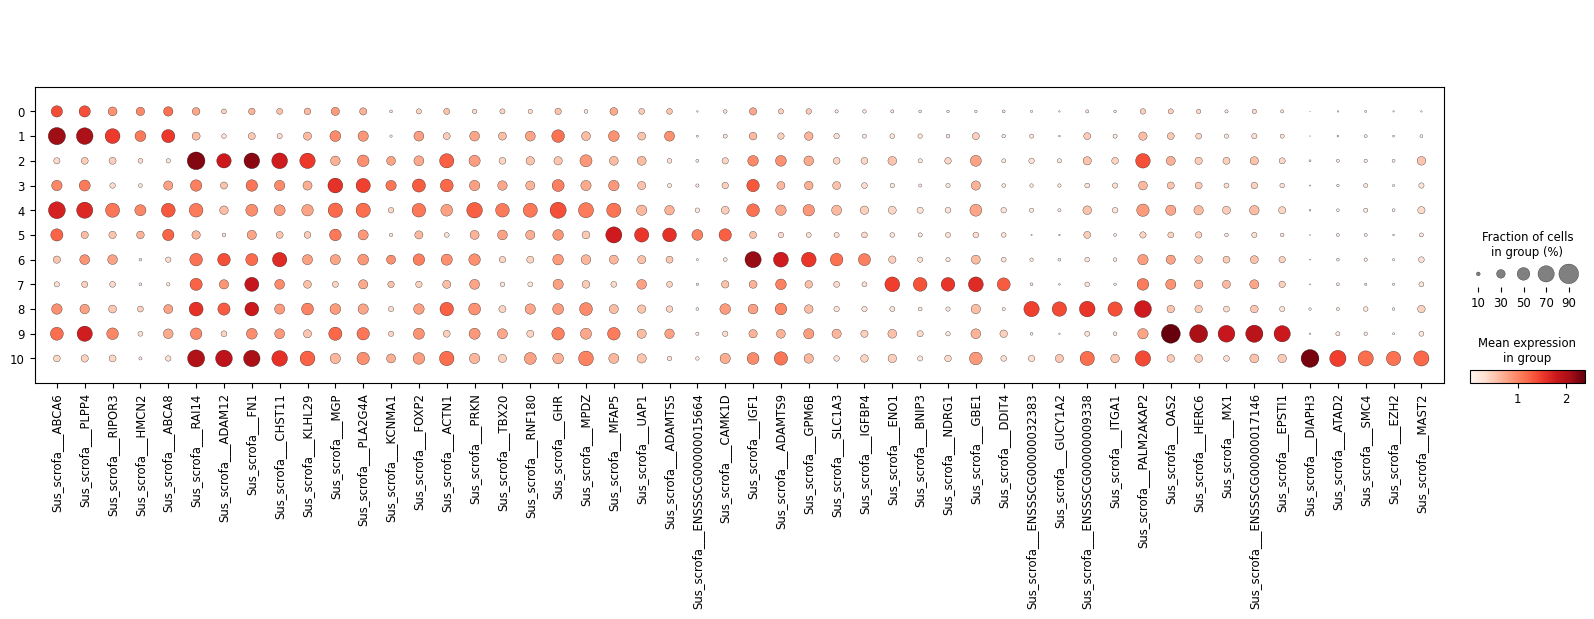

In [65]:
sc.pl.dotplot(GLOBAL_harmony,
              var_names=makevector_topmarkers(GLOBAL_harmony, 5, 
                                            ldFC_cutoff=1, 
                                            pvals_adj_cutoff=1e-10,
                                            expression_in=1,
                                             expression_out=1),
              groupby="leiden_07")

In [42]:
#sc.pl.umap(GLOBAL_harmony, color=['Sus_scrofa___CD4', 'Sus_scrofa___CD8A', 'Sus_scrofa___TOP2A',
#                                 'Sus_scrofa___F13A1', 'Sus_scrofa___THEMIS', 'Sus_scrofa___RIPOR2',
#                                  'Sus_scrofa___TTN', 'Sus_scrofa___PKP2',
#                                  'pCMV_score'],
#           projection="2d", components=['1,2'], show=True)

In [43]:
#sc.pl.umap(GLOBAL_harmony, color=['Sus_scrofa___KLRD1'],
#           projection="2d", components=['1,2'], show=True)

In [44]:
GLOBAL_harmony.obs['cell_states']=GLOBAL_harmony.obs['leiden_07']
subs = {
    "0":'vFB1',
    "1":'vFB1',
    "2":'vFB2',
    "3":'vFB3',
    "4":'vFB4',
    "5":'vFB5',
    "6":'vFB6',
    "7":'vFB7',
    '8':'vFB8',
    '9':'vFB9',
    '10':'vFB10',
     } 
x=[subs.get(item,item)  for item in GLOBAL_harmony.obs['cell_states']]
GLOBAL_harmony.obs['cell_states']=x
pd.value_counts(GLOBAL_harmony.obs['cell_states'])/GLOBAL_harmony.shape[0]

cell_states
vFB1     0.357064
vFB2     0.131908
vFB3     0.097966
vFB4     0.096373
vFB5     0.090308
vFB6     0.065249
vFB7     0.056672
vFB8     0.041355
vFB9     0.040130
vFB10    0.022975
Name: count, dtype: float64

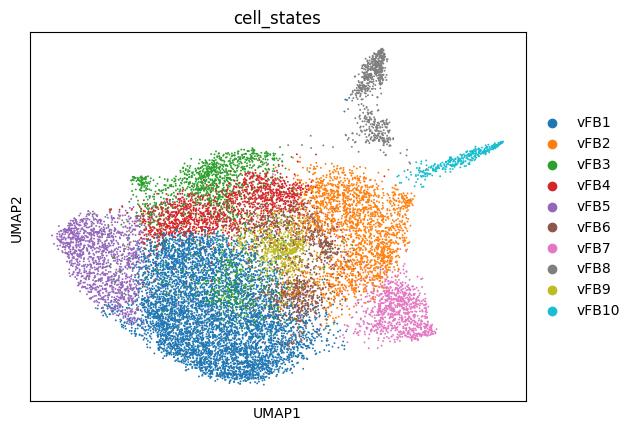

In [53]:
sc.pl.umap(GLOBAL_harmony, color=['cell_states'],
           projection="2d", components=['1,2'], show=True)

In [54]:
sc.tl.rank_genes_groups(GLOBAL_harmony, 'cell_states', method='wilcoxon', n_genes=GLOBAL_harmony.raw.X.shape[1])
df=filter_by_expression(GLOBAL_harmony, 'cell_states', key='rank_genes_groups')

In [ ]:
#GLOBAL_harmony.write(PATH_FILESYSTEM+"PROJECTS/20231020_el_Xenotransplant/results/V2/FB.h5ad")